# Phase 5a — Global LightGBM (Direct Multi-Step)

Trains one global LightGBM model over all products and all 12 forecast horizons.

**Design choices:**
- **Objective**: `tweedie` (variance power 1.2) — non-negative, zero-inflated demand
- **Multi-step**: direct (each horizon is a separate label; `horizon` is a feature)
- **Categoricals**: native LightGBM (no one-hot encoding)
- **Early stopping**: VALID RMSE, patience 50 rounds

Figures 22–25 saved to `outputs/figures/` at 140 dpi.

In [1]:
import sys, json, time
from pathlib import Path

ROOT = Path().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.training_table import get_splits, split_boundaries
from src.model_global    import train_global, load_global, DEFAULT_PARAMS, MODEL_PATH, PREDS_PATH, HIST_PATH

FIGS       = ROOT / "outputs" / "figures"
MODEL_FILE = ROOT / MODEL_PATH
PREDS_FILE = ROOT / PREDS_PATH
HIST_FILE  = ROOT / HIST_PATH
FIGS.mkdir(parents=True, exist_ok=True)
MODEL_FILE.parent.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 140,
    "figure.facecolor": "white", "axes.facecolor": "#f8f8f8",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35, "grid.color": "#cccccc",
    "font.family": "sans-serif", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "legend.frameon": False,
})

def savefig(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight", dpi=140)
    print(f"Saved -> {name}")

bounds = split_boundaries(ROOT / "data/processed/features_product.parquet")
print("Panel end :", bounds["panel_end"].date())
print("Test start:", bounds["test_start"].date(), " (12 weeks, sealed)")
print("Valid start:", bounds["valid_start"].date(), "(12 weeks)")


Panel end : 2025-09-08
Test start: 2025-06-23  (12 weeks, sealed)
Valid start: 2025-03-31 (12 weeks)


In [2]:
# ── Build training splits ─────────────────────────────────────────────────────
print("Building direct multi-step training table …")
t0 = time.time()
train_df, valid_df, test_df, feature_cols, cat_cols = get_splits(
    ROOT / "data/processed/features_product.parquet"
)
print(f"Built in {time.time()-t0:.0f}s")
print(f"  TRAIN : {len(train_df):>10,} rows")
print(f"  VALID : {len(valid_df):>10,} rows  target {valid_df['target_week'].min().date()} → {valid_df['target_week'].max().date()}")
print(f"  TEST  : {len(test_df):>10,} rows  target {test_df['target_week'].min().date()} → {test_df['target_week'].max().date()}")
print(f"  features: {len(feature_cols)}  |  categoricals: {len(cat_cols)}")
print(f"  % zero y (train): {(train_df['y']==0).mean()*100:.1f}%")


Building direct multi-step training table …


Built in 21s
  TRAIN : 13,586,560 rows
  VALID :  1,766,662 rows  target 2025-03-31 → 2025-06-16
  TEST  :  1,856,599 rows  target 2025-06-23 → 2025-09-08
  features: 48  |  categoricals: 7
  % zero y (train): 96.9%


In [3]:
# ── Train or load model ───────────────────────────────────────────────────────
if MODEL_FILE.exists() and PREDS_FILE.exists() and HIST_FILE.exists():
    print("Loading cached model …")
    booster, eval_history = load_global(MODEL_FILE, HIST_FILE)
    preds = pd.read_parquet(PREDS_FILE)
    best_iter = booster.best_iteration
    print(f"  best_iteration = {best_iter}")
else:
    print("Training global LightGBM …")
    t0 = time.time()
    booster, eval_history, preds = train_global(
        train_df, valid_df, test_df,
        feature_cols, cat_cols,
        params=DEFAULT_PARAMS,
        num_boost_round=2000,
        early_stopping_rounds=50,
        model_out=MODEL_FILE,
        hist_out=HIST_FILE,
        preds_out=PREDS_FILE,
    )
    elapsed = time.time() - t0
    best_iter = booster.best_iteration
    print(f"Training done in {elapsed/60:.1f} min  |  best_iteration = {best_iter}")

# Quick validation metrics
v = preds[preds["split"] == "valid"]
from sklearn.metrics import mean_absolute_error, mean_squared_error
valid_rmse = np.sqrt(mean_squared_error(v["y_true"], v["y_pred"]))
valid_mae  = mean_absolute_error(v["y_true"], v["y_pred"])
print(f"\nVALID RMSE = {valid_rmse:.4f}   MAE = {valid_mae:.4f}")


Training global LightGBM …


Training until validation scores don't improve for 50 rounds


[50]	train's rmse: 135.996	valid's rmse: 104.022


[100]	train's rmse: 124.703	valid's rmse: 103.914


[150]	train's rmse: 118.693	valid's rmse: 103.688


[200]	train's rmse: 113.049	valid's rmse: 103.512


[250]	train's rmse: 107.981	valid's rmse: 103.181


Early stopping, best iteration is:
[243]	train's rmse: 108.655	valid's rmse: 103.163


Training done in 3.8 min  |  best_iteration = 243

VALID RMSE = 103.1633   MAE = 7.9644


Saved -> 22_loss_curve.png


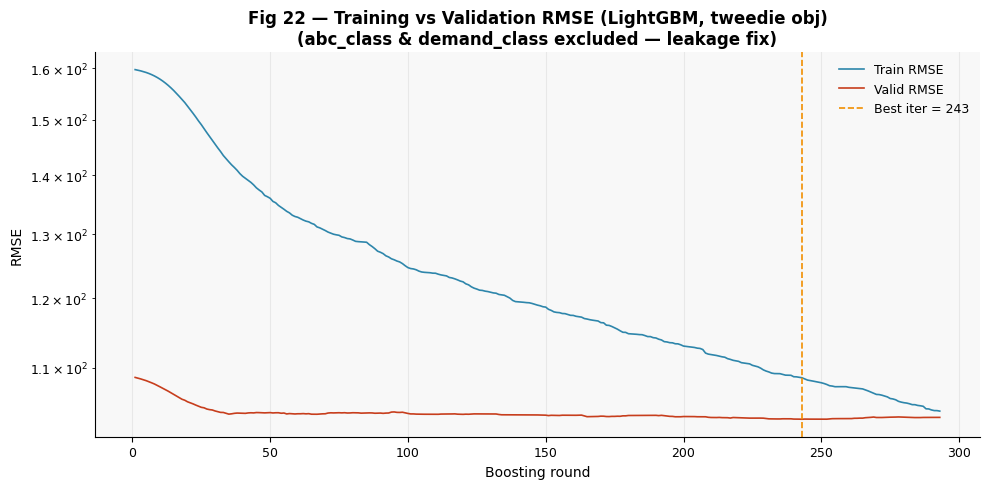

In [4]:
# ── Fig 22 — Training vs validation loss curve ────────────────────────────────
if eval_history is not None:
    train_rmse = eval_history["train"]["rmse"]
    valid_rmse_hist = eval_history["valid"]["rmse"]
    iters = range(1, len(train_rmse) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(iters, train_rmse, color="#2E86AB", linewidth=1.2, label="Train RMSE")
    ax.plot(iters, valid_rmse_hist, color="#C73E1D", linewidth=1.2, label="Valid RMSE")
    ax.axvline(booster.best_iteration, color="#F18F01", linestyle="--",
               linewidth=1.2, label=f"Best iter = {booster.best_iteration}")
    ax.set_xlabel("Boosting round")
    ax.set_ylabel("RMSE")
    ax.set_title("Fig 22 — Training vs Validation RMSE (LightGBM, tweedie obj)\n(abc_class & demand_class excluded — leakage fix)")
    ax.legend()
    ax.set_yscale("log")
    plt.tight_layout()
    savefig(fig, "22_loss_curve.png")
    plt.show()
else:
    print("eval_history not available (model loaded from cache without history).")
    print("Re-run from scratch to generate Fig 22.")


Saved -> 23_feature_importance.png


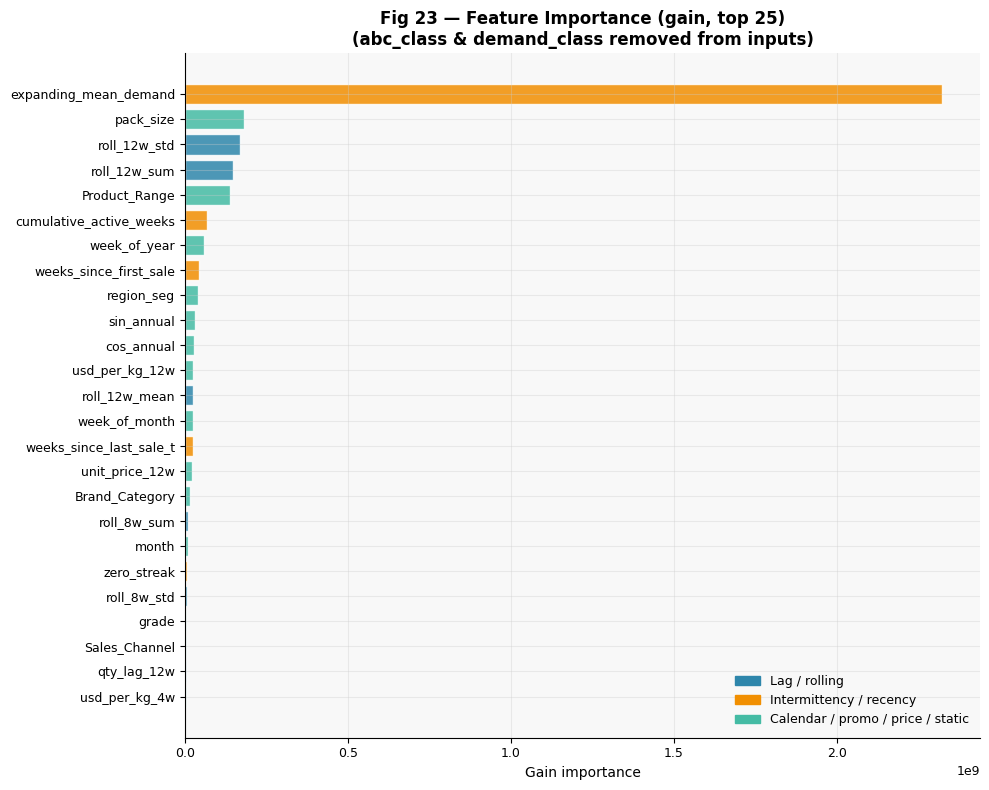

In [5]:
# ── Fig 23 — Feature importance (gain, top 25) ────────────────────────────────
imp = pd.Series(
    booster.feature_importance(importance_type="gain"),
    index=booster.feature_name(),
).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
colours = ["#2E86AB" if "lag" in n or "roll" in n else
           "#F18F01" if n in ("horizon", "weeks_since_first_sale",
                              "weeks_since_last_sale_t", "zero_streak",
                              "cumulative_active_weeks", "expanding_mean_demand") else
           "#44BBA4" for n in imp.index]
ax.barh(imp.index[::-1], imp.values[::-1], color=colours[::-1],
        alpha=0.85, edgecolor="white")
ax.set_xlabel("Gain importance")
ax.set_title("Fig 23 — Feature Importance (gain, top 25)\n(abc_class & demand_class removed from inputs)")

# Legend patches
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color="#2E86AB", label="Lag / rolling"),
    mpatches.Patch(color="#F18F01", label="Intermittency / recency"),
    mpatches.Patch(color="#44BBA4", label="Calendar / promo / price / static"),
]
ax.legend(handles=legend_patches, loc="lower right")
plt.tight_layout()
savefig(fig, "23_feature_importance.png")
plt.show()


Saved -> 24_pred_vs_actual.png


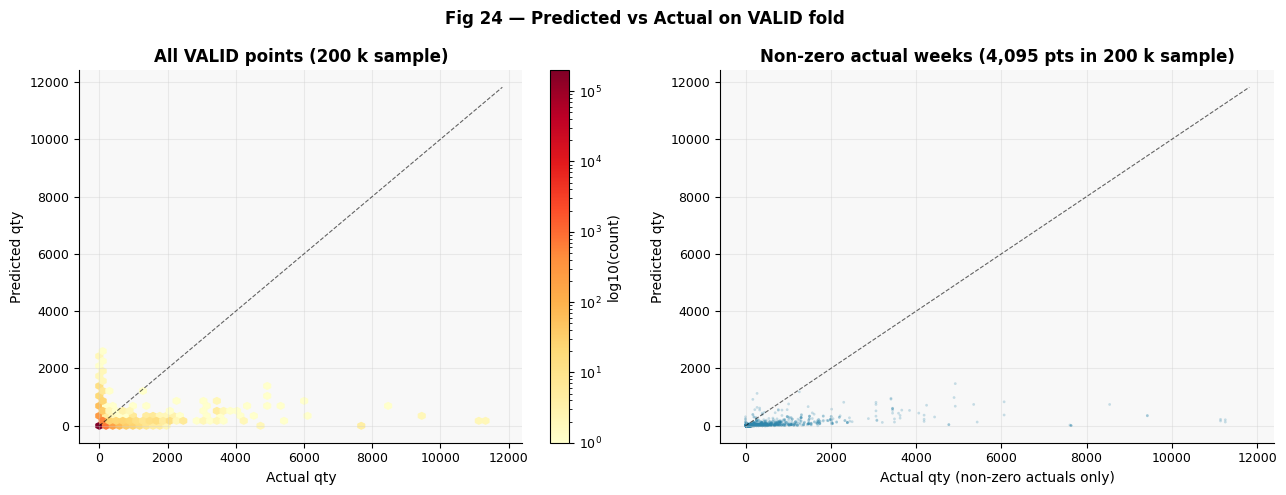

In [6]:
# ── Fig 24 — Predicted vs actual on VALID fold ────────────────────────────────
v = preds[preds["split"] == "valid"].sample(min(200_000, len(preds[preds["split"]=="valid"])),
                                             random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: all points (hexbin), log scale
ax = axes[0]
lim = max(v["y_true"].max(), v["y_pred"].max()) * 1.05
hb = ax.hexbin(v["y_true"], v["y_pred"], gridsize=60, bins="log",
               cmap="YlOrRd", mincnt=1, extent=[0, lim, 0, lim])
fig.colorbar(hb, ax=ax, label="log10(count)")
ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Actual qty")
ax.set_ylabel("Predicted qty")
ax.set_title("All VALID points (200 k sample)")

# Right: non-zero actuals only
ax2 = axes[1]
nz = v[v["y_true"] > 0]
ax2.scatter(nz["y_true"], nz["y_pred"], s=4, alpha=0.25,
            color="#2E86AB", edgecolors="none")
mx = max(nz["y_true"].max(), nz["y_pred"].max()) * 1.05
ax2.plot([0, mx], [0, mx], "k--", linewidth=0.8, alpha=0.6)
ax2.set_xlabel("Actual qty (non-zero actuals only)")
ax2.set_ylabel("Predicted qty")
ax2.set_title(f"Non-zero actual weeks ({len(nz):,} pts in 200 k sample)")

fig.suptitle("Fig 24 — Predicted vs Actual on VALID fold", fontweight="bold")
plt.tight_layout()
savefig(fig, "24_pred_vs_actual.png")
plt.show()


Saved -> 25_error_by_horizon.png


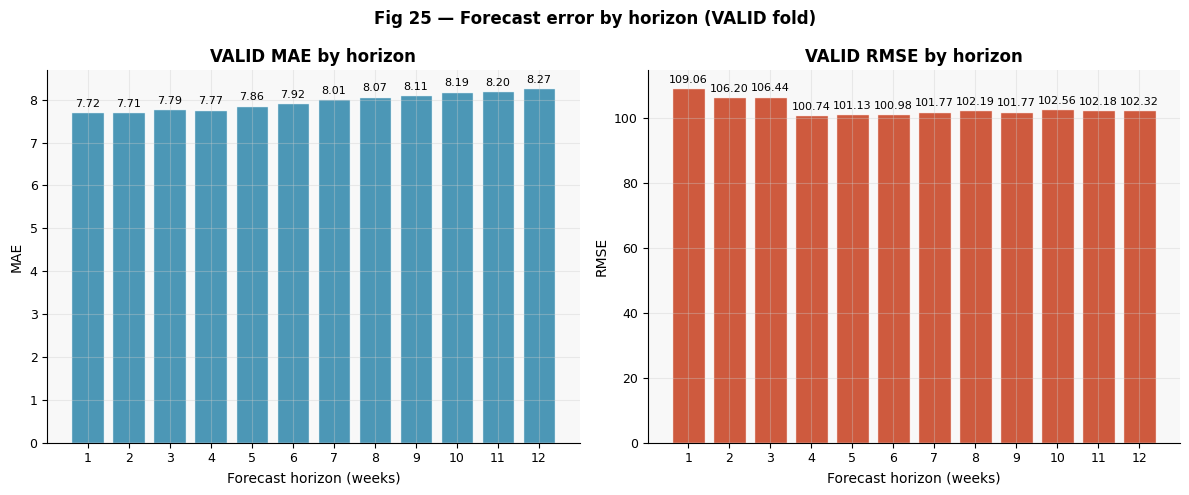


Error by horizon table:
 horizon      MAE       RMSE        n
       1 7.716131 109.064423 150381.0
       2 7.706427 106.196564 149711.0
       3 7.786036 106.443901 149130.0
       4 7.768976 100.737175 148500.0
       5 7.856586 101.127426 147984.0
       6 7.923103 100.975624 147466.0
       7 8.010620 101.769691 146887.0
       8 8.069793 102.194420 146372.0
       9 8.105501 101.770325 145865.0
      10 8.188274 102.562294 145346.0
      11 8.199849 102.177864 144772.0
      12 8.270753 102.316383 144248.0


In [7]:
# ── Fig 25 — Error by horizon (MAE for h=1..12 on VALID) ─────────────────────
v_all = preds[preds["split"] == "valid"].copy()
by_h = (
    v_all.groupby("horizon")
    .apply(lambda g: pd.Series({
        "MAE":  mean_absolute_error(g["y_true"], g["y_pred"]),
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "n":    len(g),
    }), include_groups=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(by_h["horizon"], by_h["MAE"],  color="#2E86AB", alpha=0.85, edgecolor="white")
axes[1].bar(by_h["horizon"], by_h["RMSE"], color="#C73E1D", alpha=0.85, edgecolor="white")

for ax, metric in zip(axes, ["MAE", "RMSE"]):
    ax.set_xlabel("Forecast horizon (weeks)")
    ax.set_ylabel(metric)
    ax.set_xticks(range(1, 13))
    ax.set_title(f"VALID {metric} by horizon")
    for bar, val in zip(ax.patches, by_h[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Fig 25 — Forecast error by horizon (VALID fold)", fontweight="bold")
plt.tight_layout()
savefig(fig, "25_error_by_horizon.png")
plt.show()

print("\nError by horizon table:")
print(by_h[["horizon","MAE","RMSE","n"]].to_string(index=False))


In [8]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("=" * 65)
print("PHASE 5a GLOBAL LIGHTGBM SUMMARY")
print("=" * 65)
print(f"  Best iteration   : {booster.best_iteration}")
print(f"  n_features       : {len(feature_cols)}")
print(f"  Train rows       : {len(train_df):,}")
print(f"  Valid rows       : {len(valid_df):,}")
print(f"  Test  rows       : {len(test_df):,}  (sealed — not used for selection)")
v_check = preds[preds["split"]=="valid"]
t_check = preds[preds["split"]=="test"]
print(f"  VALID RMSE       : {np.sqrt(mean_squared_error(v_check['y_true'],v_check['y_pred'])):.4f}")
print(f"  VALID MAE        : {mean_absolute_error(v_check['y_true'],v_check['y_pred']):.4f}")
print()
print("Phase 5a figures saved:")
for f in sorted(p for p in FIGS.iterdir() if p.suffix==".png" and int(p.stem[:2])>=22):
    print(f"  {f.name}  ({f.stat().st_size//1024} KB)")
print()
print("Artefacts:")
print(f"  {MODEL_FILE}")
print(f"  {HIST_FILE}")
print(f"  {PREDS_FILE}")


PHASE 5a GLOBAL LIGHTGBM SUMMARY
  Best iteration   : 243
  n_features       : 48
  Train rows       : 13,586,560
  Valid rows       : 1,766,662
  Test  rows       : 1,856,599  (sealed — not used for selection)


  VALID RMSE       : 103.1633
  VALID MAE        : 7.9644

Phase 5a figures saved:
  22_loss_curve.png  (70 KB)
  23_feature_importance.png  (89 KB)
  24_pred_vs_actual.png  (93 KB)
  25_error_by_horizon.png  (50 KB)

Artefacts:
  /Users/nethmini/Documents/GitHub/Cinnamon-Export-Sales-Forecasting/outputs/models/lgbm_global.txt
  /Users/nethmini/Documents/GitHub/Cinnamon-Export-Sales-Forecasting/outputs/models/lgbm_eval_history.json
  /Users/nethmini/Documents/GitHub/Cinnamon-Export-Sales-Forecasting/data/processed/preds_global.parquet
